In [ ]:
# Install dependencies if needed
!pip install nilearn nibabel matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 52.5 MB/s eta 0:00:00


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting, input_data, image, datasets
from scipy.stats import zscore, pearsonr
import os


In [ ]:
from google.colab import files

print("⬆️ Upload your bold.nii.gz and hippocampus_mask.nii.gz (or skip to use built-in mask)")
uploaded = files.upload()


⬆️ Upload your bold.nii.gz and hippocampus_mask.nii.gz (or skip to use built-in mask)


Saving masked (1).nii.gz to masked (1).nii.gz


In [ ]:
# check successful upload and rename file
bold_filename = "masked (1).nii.gz"
bold_img = nib.load(bold_filename)
print("✅ Loaded bold image with shape:", bold_img.shape)


✅ Loaded bold image with shape: (64, 64, 36, 164)


In [ ]:
import nibabel as nib
import numpy as np

# Load the aseg file from brainlife
aseg_img = nib.load("subj_aparc+aseg_cp.nii.gz")
aseg_data = aseg_img.get_fdata()

# Create binary mask: combine left (17) and right (53) sides
hippo_mask_data = np.isin(aseg_data, [17, 53]).astype(np.uint8)

# Save mask as new NIfTI file
hippo_mask_img = nib.Nifti1Image(hippo_mask_data, aseg_img.affine)
nib.save(hippo_mask_img, "hippocampus_mask.nii.gz")

print("✅ Hippocampus mask saved as hippocampus_mask.nii.gz")


✅ Hippocampus mask saved as hippocampus_mask.nii.gz


In [ ]:
hippo_mask = nib.load("hippocampus_mask.nii.gz")

/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

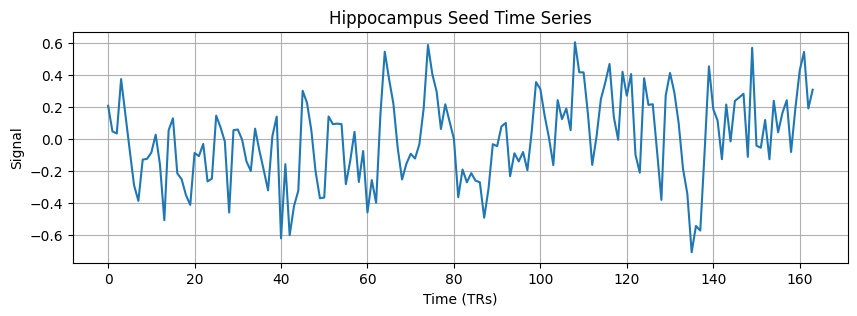

In [ ]:
masker = input_data.NiftiMasker(mask_img=hippo_mask, standardize=True)
hippo_ts = masker.fit_transform(bold_img)

# Average across all hippocampus voxels
hippo_mean_ts = np.mean(hippo_ts, axis=1)

plt.figure(figsize=(10, 3))
plt.plot(hippo_mean_ts)
plt.title("Hippocampus Seed Time Series")
plt.xlabel("Time (TRs)")
plt.ylabel("Signal")
plt.grid()
plt.show()

In [ ]:
# Voxel-wise correlation to hippocampus time series
#extract left and right to make average
brain_masker = input_data.NiftiMasker(standardize=True)
bold_ts = brain_masker.fit_transform(bold_img)

#calculate correlation between that signal and other voxels
correlation_map = np.array([
    pearsonr(hippo_mean_ts, voxel_ts)[0] for voxel_ts in bold_ts.T
])

# Fisher Z-transform to normalize results
z_map = np.arctanh(correlation_map)
z_img = brain_masker.inverse_transform(z_map)


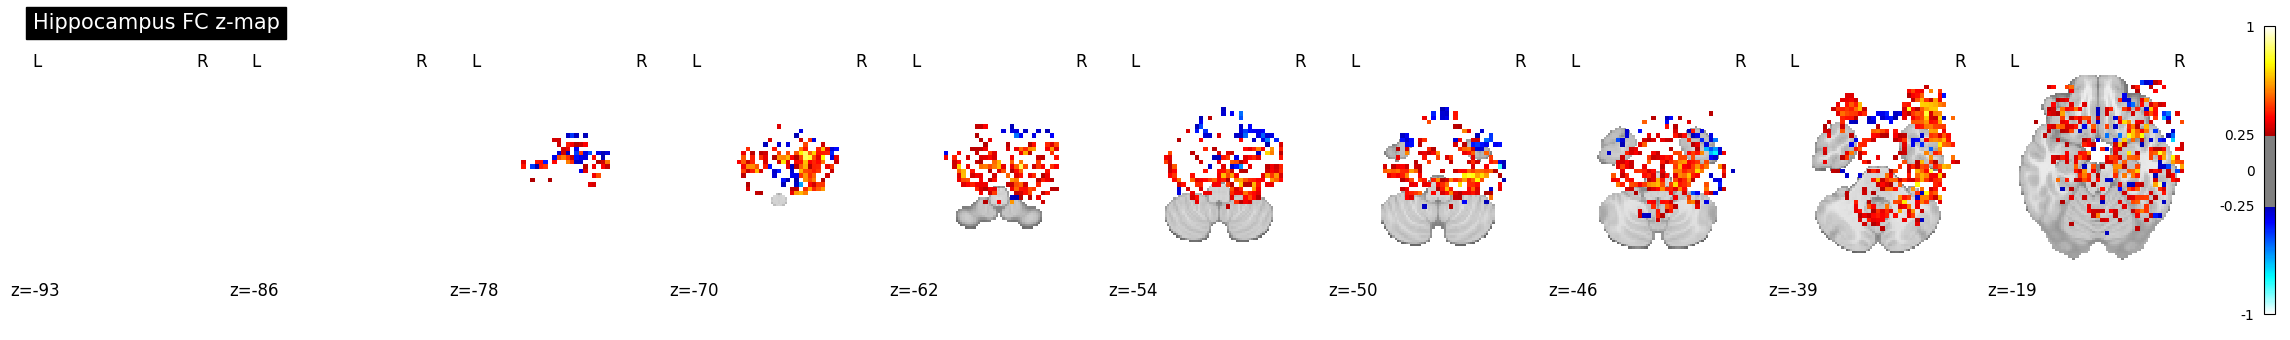

✅ Saved: hippocampus_fc_zmap.nii.gz


In [ ]:
# Show the Fisher Correlation Map
#red voxels are strongly correlated with hippocampus and blue voxels are negatively correlated
plotting.plot_stat_map(z_img, threshold=0.25, display_mode='z', cut_coords=10,
                       title="Hippocampus FC z-map", colorbar=True)
plt.show()

# Save as NIfTI
nib.save(z_img, "hippocampus_fc_zmap.nii.gz")
print("✅ Saved: hippocampus_fc_zmap.nii.gz")